In [5]:
import pandas as pd
import numpy as np

In [6]:
data=pd.read_csv('./bedtime_screentime_sleep_debt.csv')

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   str    
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   str    
 3   occupation_type           8500 non-null   str    
 4   chronotype                8500 non-null   str    
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   primary_bedtime_app       8500 non-null   str    
 7   screen_brightness_pct     8500 non-null   int64  
 8   blue_light_filter_active  8500 non-null   int64  
 9   caffeine_post_5pm_mg      8500 non-null   int64  
 10  physical_activity_min     8500 non-null   int64  
 11  sleep_latency_min         8500 non-null   float64
 12  total_sleep_hours         8500 non-null   float64
 13  deep_sleep_pct            8500 non-null   float64
 14  rem_sleep_pct      

In [8]:
data=data.drop(columns=['deep_sleep_pct','rem_sleep_pct','morning_alarm_snoozes','user_id','next_day_fatigue_score'])

In [9]:
for i in data.columns.tolist():
  print(i,data[i].unique())

age [29 58 41 36 23 20 49 40 18 60 47 24 27 33 30 26 22 28 31 44 19 57 45 21
 39 32 53 38 34 43 56 52 54 46 63 37 51 25 42 55 50 59 35 48 61 64 65 62]
gender <StringArray>
['Female', 'Non-Binary', 'Male']
Length: 3, dtype: str
occupation_type <StringArray>
['Healthcare / Shift Worker',                   'Student',
               'Remote Tech',      'Freelance / Creative',
          'Corporate 9-to-5']
Length: 5, dtype: str
chronotype <StringArray>
['Intermediate', 'Night Owl', 'Morning Lark']
Length: 3, dtype: str
bedtime_phone_minutes [179 163 100  34  27  76  53 113  65  70  23  29  58  47  42  28  15  36
  48  50 111   8 151  81  56  26  38  79  30  84  52  22  77 105  20  19
 108  71  67  57 114  59  40 180  11   9  25  37  39  66 165 125  49  12
  46  89  88  13  62  91  93 117  43  44 110 129  14  63   5 107  18 134
  31   2  54  51  16  94  98 175  85 101  55  97  96  69  73   3  21 142
 122  41  83  32  45 119 155 102  24  64  95  80  99  10   4 118 128 130
  61  75  72  17 161

In [10]:
data

,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,sleep_debt_category
0,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,Severe Sleep Debt
1,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,Severe Sleep Debt
2,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,Severe Sleep Debt
3,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,Mild Deficit
4,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,Moderate Debt
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8495,61,Female,Remote Tech,Night Owl,18,Streaming (Netflix/Hulu),61,1,60,74,21.0,5.57,Moderate Debt
8496,64,Male,Student,Night Owl,138,TikTok / Reels,58,1,0,58,84.3,3.99,Severe Sleep Debt
8497,34,Male,Corporate 9-to-5,Intermediate,56,Streaming (Netflix/Hulu),56,0,94,33,40.6,7.58,Mild Deficit
8498,23,Male,Healthcare / Shift Worker,Night Owl,165,TikTok / Reels,72,0,0,52,123.3,3.20,Severe Sleep Debt


In [11]:
data.describe()

,age,bedtime_phone_minutes,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours
count,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000,8500.000000
mean,34.355647,59.250000,55.153882,0.467765,33.222471,35.701412,40.671471,6.266209
std,11.584259,36.931991,19.850550,0.498989,51.935645,20.819390,17.444914,1.446258
min,18.000000,1.000000,10.000000,0.000000,0.000000,0.000000,6.000000,3.200000
25%,25.000000,31.000000,42.000000,0.000000,0.000000,21.000000,28.200000,5.240000
50%,32.000000,51.000000,55.000000,0.000000,0.000000,35.000000,37.600000,6.330000
75%,42.000000,79.000000,69.000000,1.000000,55.000000,50.000000,49.700000,7.350000
max,65.000000,180.000000,100.000000,1.000000,250.000000,112.000000,123.300000,9.800000


In [12]:
data['is_Caffiene>0']=np.where(data['caffeine_post_5pm_mg']>0,1,0)

In [13]:
data['is_activity_0']=np.where(data['physical_activity_min']==0,0,1)

<Axes: xlabel='total_sleep_hours', ylabel='Count'>

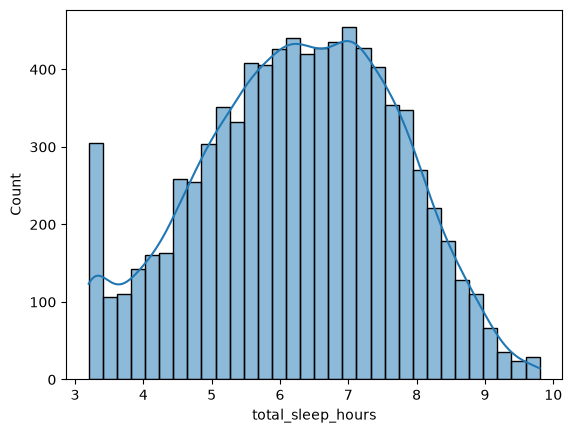

In [14]:
import seaborn as sns
sns.histplot(data['total_sleep_hours'],kde=True)

# Ensembles

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score
from sklearn.model_selection import train_test_split

In [16]:
y=data['sleep_debt_category']
x=data.drop(columns='sleep_debt_category')

In [17]:
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

ohe=['gender','occupation_type','chronotype','primary_bedtime_app']
ct1=ColumnTransformer([
    ('ohe',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe)],remainder='passthrough')

xTrain=ct1.fit_transform(xTrain)
xTest=ct1.fit_transform(xTest)

In [19]:
le=LabelEncoder()
yTrain=le.fit_transform(yTrain)
yTest=le.transform(yTest)

In [20]:
models={
    'dtc':DecisionTreeClassifier(max_depth=7,min_samples_split=5,min_samples_leaf =4),
    'rfc':RandomForestClassifier(max_depth=7,min_samples_split=5,min_samples_leaf =4,bootstrap=True,class_weight="balanced"),
    'xgb':xgb.XGBClassifier(
      num_class=3,
      random_state=42,
      n_estimators=100,
      learning_rate=0.05
    )
}

In [21]:
acc=[]
for mod in models.items():
  model=mod[1]
  model.fit(xTrain,yTrain)
  y_pred=model.predict(xTest)
  accuracy=acc.append(accuracy_score(yTest,y_pred))
  print("Accuracy",accuracy_score(yTest,y_pred))
  print("Confusion Matrix",confusion_matrix(yTest,y_pred))
  print("Precision",precision_score(yTest,y_pred,average='weighted'))
  print("Recall",recall_score(yTest,y_pred,average='weighted'))
  print('\n')

Accuracy 0.96
Confusion Matrix [[374   0   0   0]
 [  0 881   0  22]
 [  0   0 279   0]
 [  0  46   0  98]]
Precision 0.9581123167713687
Recall 0.96


Accuracy 0.9558823529411765
Confusion Matrix [[374   0   0   0]
 [  0 834   0  69]
 [  0   0 279   0]
 [  0   6   0 138]]
Precision 0.9679705882352942
Recall 0.9558823529411765


Accuracy 0.9664705882352941
Confusion Matrix [[372   0   2   0]
 [  0 882   0  21]
 [  2   0 277   0]
 [  0  32   0 112]]
Precision 0.9656754577910861
Recall 0.9664705882352941




In [22]:
model_dict={
    'Models':['dtc','rfc','xgb'],
    'Accuracy':acc
}
accuracy_df=pd.DataFrame(model_dict)
accuracy_df

,Models,Accuracy
0,dtc,0.960000
1,rfc,0.955882
2,xgb,0.966471


In [23]:
import joblib
joblib.dump(models['xgb'],'xgb_model_classifier.pkl')
joblib.dump(ct1,'column_transformer_classifier.pkl')

['column_transformer_classifier.pkl']

# Logistic Regression


In [24]:
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

ohe=['gender','occupation_type','chronotype','primary_bedtime_app']
ss=['caffeine_post_5pm_mg','sleep_latency_min','total_sleep_hours','bedtime_phone_minutes']

ct1=ColumnTransformer([
    ('ohe',OneHotEncoder(handle_unknown='ignore',drop='first'),ohe),
    ('ss',StandardScaler(),ss),
    ('mm',MinMaxScaler(),['age'])
    ],remainder='passthrough')


In [26]:
le=LabelEncoder()
yTrain=le.fit_transform(yTrain)
yTest=le.transform(yTest)

In [27]:
pp1=Pipeline([
    ('preprocess1',ct1),
    ('model',LogisticRegression())
])

In [28]:
pp1.fit(xTrain,yTrain)
y_pred=pp1.predict(xTest)

print("Accuracy",accuracy_score(yTest,y_pred))
print("Confusion Matrix",confusion_matrix(yTest,y_pred))
print("Precision",precision_score(yTest,y_pred,average='weighted'))
print("Recall",recall_score(yTest,y_pred,average='weighted'))

Accuracy 0.8805882352941177
Confusion Matrix [[324  22  28   0]
 [ 31 842   0  30]
 [ 45   0 234   0]
 [  0  47   0  97]]
Precision 0.8804196386044204
Recall 0.8805882352941177


C:\Users\Sulav Dhami\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       8500 non-null   int64  
 1   gender                    8500 non-null   str    
 2   occupation_type           8500 non-null   str    
 3   chronotype                8500 non-null   str    
 4   bedtime_phone_minutes     8500 non-null   int64  
 5   primary_bedtime_app       8500 non-null   str    
 6   screen_brightness_pct     8500 non-null   int64  
 7   blue_light_filter_active  8500 non-null   int64  
 8   caffeine_post_5pm_mg      8500 non-null   int64  
 9   physical_activity_min     8500 non-null   int64  
 10  sleep_latency_min         8500 non-null   float64
 11  total_sleep_hours         8500 non-null   float64
 12  sleep_debt_category       8500 non-null   str    
 13  is_Caffiene>0             8500 non-null   int64  
 14  is_activity_0      